# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

## Adtividad de Semana 7

### **Campañas publicitarias en redes sociales - Modelos de Regresión**



### **Nombre:**
CARLOS FERNANDO DEL CASTILLO REY
### **Matrícula:**
A01796595

### **Trabajaremos con el archivo "dataset_Facebook.csv" que encuentras en la siguiente liga:**

https://archive.ics.uci.edu/dataset/368/facebook+metrics

### **Estos datos están asociados al siguiente artículo de Moro et.al. de ELSEVIER, que deberás descargar para contestar varias de las preguntas de esta actividad (el acceso es sin costo alguno):**

https://www.semanticscholar.org/paper/Predicting-social-media-performance-metrics-and-of-Moro-Rita/dec55692590820754b53c916e29bb2b42c0e5104


### **NOTA: No modifiques el código, salvo en las partes que se te indica.**

In [91]:
# Puedes incluir más librerías, de ser necesario:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder, FunctionTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

from sklearn import metrics
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve


import warnings
warnings.filterwarnings('ignore')

## **Ejercicio 1**


### **Describe en qué consiste el método llamado de "Curvas de Aprendizaje" (Learning Cures), para monitorear el subentrenamiento o sobrbeentrenamiento de un modelo.**

#### NOTA: Puedes apoyarte en la documentación de sklearn:

https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html#sphx-glr-auto-examples-model-selection-plot-learning-curve-py



### ++++++++ Inicia la sección de agregar texto: +++++++++++




### ++++++++ Termina la sección de agregar texto. +++++++++++

## **Ejercicio 2**

### **De acuerdo al artículo de Moro et.al. de ELSEVIER, contesta las siguientes preguntas:**

*   **a. ¿Cuál es el objetivo del problema que se plantea en el artículo?**


### ++++++++ Inicia la sección de agregar texto: +++++++++++


Tiene como objetivo principal predecir el rendimiento de las publicaciones en páginas de Facebook de marcas mediante técnicas de minería de datos.

En particular, se busca modelar métricas de desempeño de las publicaciones con base en variables de entrada, como el tipo de contenido, la cantidad de seguidores de la página, el mes y la hora de publicación, entre otras.

A través del análisis de sensibilidad, los autores también exploran la influencia de estas variables en el modelo, identificando cuáles son los factores clave que afectan la interacción de los usuarios con las publicaciones.

### ++++++++ Termina la sección de agregar texto. +++++++++++


*   **b. Describe a continuación el significado de cada una de las 8 variables con la cuales trabajaremos, de acuerdo a la información de las Tablas 2 y 3 del artículo de Moro et.al.**

### ++++++++ Inicia la sección de agregar texto: +++++++++++


1-Category: Clasificación manual del contenido publicado en Facebook. Se divide en:

1.1-Action: Ofertas especiales y concursos.
1.2-Product: Contenido de publicidad explícita de la marca.
1.3-Inspiration: Contenido relacionado con la marca, pero no explícitamente publicitario.

2.-Page total likes: Número total de personas que han dado "Me gusta" a la página de la empresa en Facebook.

3-Type: Tipo de contenido publicado en Facebook. Puede ser:

3.1-Link: Publicación con un enlace.
3.2-Photo: Publicación con una imagen.
3.3-Status: Publicación de solo texto.
3.4-Video: Publicación con un video.

4-Post month: Mes en el que se publicó la publicación en Facebook (Enero, Febrero, ..., Diciembre).

5-Post hour: Hora del día en la que se publicó la publicación en Facebook (de 0 a 23 horas).

6-Post weekday: Día de la semana en el que se publicó la publicación (Domingo, Lunes, ..., Sábado).

7-Paid: Indica si la publicación fue promocionada mediante pago en Facebook (Sí/No).

8-Lifetime post consumers: Número de personas que hicieron clic en cualquier parte de la publicación en Facebook.

### ++++++++ Termina la sección de agregar texto. +++++++++++

### **En esta actividad trabajarás solamente con el ajuste de modelos, por lo que la parte de procesamiento no la debes modificar. Solo haremos unos ajustes mínimos.**

In [92]:
# Cargamos los datos del archivo:


data = pd.read_csv("D:\\Mestria\\ML\\DATA.csv", sep=';', header='infer')
print('Total de registros y variables:',data.shape)
data.head(3).T

Total de registros y variables: (500, 19)


,0,1,2
Page total likes,139441,139441,139441
Type,Photo,Status,Photo
Category,2,2,3
Post Month,12,12,12
Post Weekday,4,3,3
Post Hour,3,10,3
Paid,0.0,0.0,0.0
Lifetime Post Total Reach,2752,10460,2413
Lifetime Post Total Impressions,5091,19057,4373
Lifetime Engaged Users,178,1457,177


## **Ejercicio 3**

### **Variables temporales**

### **Recordemos que las varaibles temporales pueden tratarse como variables categóricas o numéricas, dependiendo del contexto. En nuestro caso las variables mes, día de la semana y hora en que se puso el post, podríamos considerarlas como variables categóricas ordinales. Sin embargo, para recordar cómo se transforman en cada uno de estos casos (numéricas y categóricas), consideraremos las variables de mes y día de la semana como categóricas ordinales y la variable hora como una variable cíclica.**

### **En la Tabla 3 del artículo de ELSEVIER nos comentan que la variable Post_hour está etiquetada de 0 a 23, por lo que las 24 horas serían las 0 horas, es decir tiene un comportamiento cíclico de 24 horas, que en términos matemáticos se dice que es una variable cíclica módulo 24. Así, las 24 horas será equivalente a las 0 horas**

### **La manera de transformar una variable T cíclica módulo M, es sustituyendo la columna original de la variable T por las siguientes dos columnas. Es lo que se llama ingeniería de características (feature engineering) dentro del área de ciencia de datos:**

$Tsin = sin(2*\pi*T/M)$

$Tcos = cos(2*\pi*T/M)$

#### NOTA: Donde se indica None, podrás agregar las líneas de código que consideres necesarias.

In [93]:
# Ejercicio 3a:

# Define las dos nuevas variables, "horas_sin" y "horas_cos" a partir de la
# variable "Post Hour" y de acuerdo a como se indicó previamente:


# ++++++++++++++ Incluye aquí tu código ++++++++++++++++++++++++++++++

horas_sin =  np.sin(2 * np.pi * data['Post Hour'] / 24)
horas_cos =  np.cos(2 * np.pi * data['Post Hour'] / 24)


# +++++++++++++ Tesrmina sección de agregar código +++++++++++++++++++++

In [94]:
# Ejercicio 3b:

# Agrega estas dos nuevas variables al DataFrame de tus datos
# y elimina la columna de la variable original "Post Hour":

# ++++++++++++++ Incluye aquí tu código ++++++++++++++++++++++++++++++

data = data.drop(columns=['Post Hour'])
data['horas_cos']=horas_cos
data['horas_sin']=horas_sin
# +++++++++++++ Termina sección de agregar código +++++++++++++++++++++


# Veamos lo que tenemos hasta el momento:
data.head(3).T

,0,1,2
Page total likes,139441,139441,139441
Type,Photo,Status,Photo
Category,2,2,3
Post Month,12,12,12
Post Weekday,4,3,3
Paid,0.0,0.0,0.0
Lifetime Post Total Reach,2752,10460,2413
Lifetime Post Total Impressions,5091,19057,4373
Lifetime Engaged Users,178,1457,177
Lifetime Post Consumers,109,1361,113


In [95]:
# De las Tablas 2 y 3 del artículo de ELSEVIER seleccionamos las variables que
# trabajaremos en esta Actividad.

# Separamos los datos de entrada (ver Tabla 3 del artículo) y de la variable de salida (ver Tabla 2):
X = data[['Page total likes', 'Type', 'Category', 'Post Month', 'Post Weekday', 'Paid', 'horas_sin', 'horas_cos']]
y = data[['Lifetime Post Consumers']]   # Hay 12 variables de salida, pero solo trabajaremos con la
                                        # que se consideró la más importante en el artículo de ELSEVIER.


# Particionamos en Train, Validation y Test en 70-15-15:
Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=7)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, shuffle=True, random_state=7)


print('Train:', Xtrain.shape, ytrain.shape)
print('Val:', Xval.shape, yval.shape)
print('Test:', Xtest.shape, ytest.shape)

Train: (350, 8) (350, 1)
Val: (75, 8) (75, 1)
Test: (75, 8) (75, 1)


In [96]:
Xtrain.describe(include='all').T   # Veamos alguna descripción como datos numéricos del conjunto de entrenamiento.
                                   # En particular, las desviaciones estándar (std) desplegadas son las muestrales.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Page total likes,350.0,NaN,NaN,NaN,123412.534286,16145.534825,81370.0,111972.0,129600.0,136393.0,139441.0
Type,350,4,Photo,301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,350.0,NaN,NaN,NaN,1.9,0.862295,1.0,1.0,2.0,3.0,3.0
Post Month,350.0,NaN,NaN,NaN,7.088571,3.309383,1.0,4.0,7.0,10.0,12.0
Post Weekday,350.0,NaN,NaN,NaN,4.151429,2.047414,1.0,2.0,4.0,6.0,7.0
Paid,349.0,NaN,NaN,NaN,0.286533,0.452791,0.0,0.0,0.0,1.0,1.0
horas_sin,350.0,NaN,NaN,NaN,0.443653,0.45043,-1.0,0.258819,0.5,0.707107,1.0
horas_cos,350.0,NaN,NaN,NaN,-0.191939,0.75209,-1.0,-0.866025,-0.5,0.707107,0.965926


### **Ajuste variable categórica en Pipeline**

#### **Veamos un ejemplo de cómo ajustar una variable categórica en la cual uno de sus niveles no tiene suficiente información, por ejemplo, que no tenga al menos un 5% de información cada nivel. Entonces reagruparemos los niveles más pequeños hasta obtener un 5% y esto mediante una función que podamos usar dentro del Pipeline, para evitar el filtrado de información.**

In [97]:
# Obtengamos las etiquetas únicas de data['Type'] ordenadas de mayor a menor frecuencia:
Xtrain['Type'].unique()

array(['Photo', 'Status', 'Link', 'Video'], dtype=object)

In [98]:
Xtrain['Type'].value_counts() / Xtrain.shape[0]   # Siguiendo la política de que cada nivel de una variable tenga
                                                  # al menos el 5% de información, agruparemos los casos "Link"
                                                  # y "Video" en un nuevo nivel que podría interpretarse como "Otros".

Type
Photo     0.860000
Status    0.082857
Link      0.045714
Video     0.011429
Name: count, dtype: float64

In [99]:
# Definimos la función que llevará a cabo esta transformación dentro del Pipeline:

def mi_type(x):
  x = x.values.ravel()  # Convertimos a un arreglo 1D
  x = pd.Series(x, name='Type')  # seleccionamos la columna como datos tipo Series
  x.loc[:] = x.map({'Photo':1, 'Status':2, 'Link':0, 'Video':0})  # Podrías etiquetarlos también como 3, en lugar de 0.
  return x.values.reshape(-1, 1)    # Ajustamos la dimensión a un vector columna.

### **Transformación en la Variable de Salida**



In [100]:
ytrain.describe().T   # Información de la variable de salida.

,count,mean,std,min,25%,50%,75%,max
Lifetime Post Consumers,350.0,780.517143,770.963085,9.0,336.75,543.0,959.0,5934.0


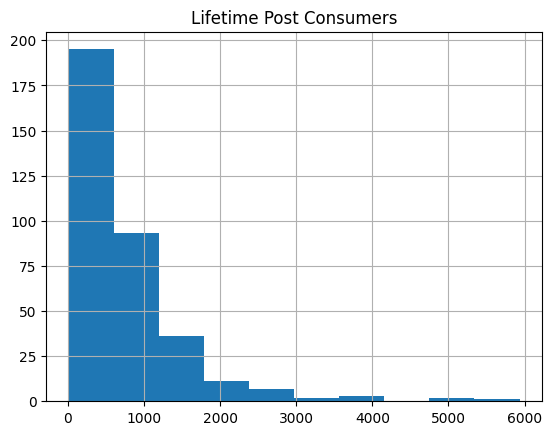

In [101]:
# Observamos a continuación que hay un claro sesgo positivo en la variable de salida:
ytrain.hist();

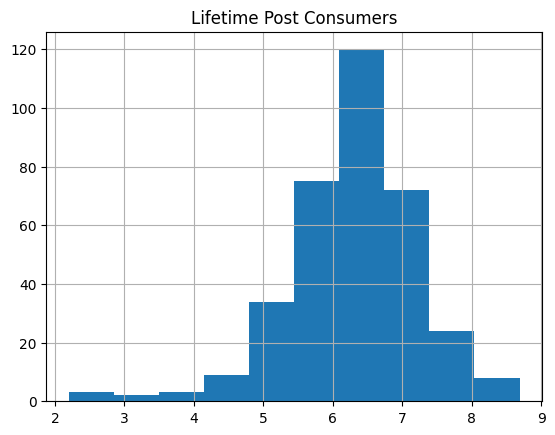

In [102]:
ytrainlog = np.log(ytrain)   # Recordemos que nuestra variable de salida en un problema
ytrainlog.hist();            # de Regresión se recomienda que esté aproximadamente
                             # acampanada, por lo que la ajustaremos con el logaritmo
                             # natural como primera aproximación.

In [103]:
# Para una primera aproximación, podemos decir que se ajusta de manera aceptable
# la distribución con logaritmo a una acampanada.
# Procedemos entonces de la misma manera con Val y Test:
yvallog = np.log(yval)
ytestlog = np.log(ytest)

In [104]:
# Aplicaremos lo mínimo de transformaciones.
# Las nuevas variables horas_sin y horas_cos ya están escaladas entre -1 y +1, por
# lo que podemos dejarlas así y solamente cuidar sus posibles datos perdidos.

num_pipe = Pipeline(steps = [('numImp', SimpleImputer(strategy='median')),
                             ('scaler', MinMaxScaler())
                             ])
num_pipe_nombres = [0]   # ['Page total likes']  puedes indicar solamente el índice de la columna.


# Las ordinales las identificamos como tales:
ord_pipe = Pipeline(steps =  [('OrdImp', SimpleImputer(strategy='most_frequent')),
                              ('Ordfun', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1 ))
                              ])
ord_pipe_nombres = [3,4]   # ['Post Month', 'Post Weekday']


# Transformación del factor categórico de entrada "Type":
catMap_pipe = Pipeline(steps = [('catMap', FunctionTransformer(mi_type))])
catMap_pipe_nombres = ['Type']


# Las nominales las transformamos con One-Hot-Encoder:
nom_pipe = Pipeline(steps = [('NomImp', SimpleImputer(strategy='most_frequent')),
                             ('ohe', OneHotEncoder(drop='first',
                                                   handle_unknown='ignore',
                                                   ))])
nom_pipe_nombres = [1,2,5]  # ['Type', 'Category', 'Paid']


# Variables numéricas con la hora:
hora_pipe = Pipeline(steps = [('HoraImp', SimpleImputer(strategy='mean'))])
hora_pipe_nombres = [6,7]   # ['horas_sin', 'horas_cos']


# Conjuntamos las transformaciones que aplicaremos:
columnasTransformer = ColumnTransformer(transformers = [('numpow', num_pipe, num_pipe_nombres),
                                                        ('catOrd', ord_pipe, ord_pipe_nombres),
                                                        ('catNom', nom_pipe, nom_pipe_nombres),
                                                        ('catmap', catMap_pipe, catMap_pipe_nombres),
                                                        ('hora', hora_pipe, hora_pipe_nombres)
                                                        ],
                                        remainder='passthrough')



# Solo para saber la nueva cantidad de columnas después de las trasnformaciones:
XtrainT = columnasTransformer.fit_transform(Xtrain)  # Ajustamos con Train...
print('Variables de entrada original:', Xtrain.shape)
print('Variables de entrada transformadas:', XtrainT.shape)

Variables de entrada original: (350, 8)
Variables de entrada transformadas: (350, 12)


### **Criterio para determinar si un modelo está subentrenado en un problema de Regresión:**

In [105]:
# Existen varios criterios para determinar si un modelo de regresión está
# subentrenado, veamos a continuación unos de ellos.

# El valor de RMSE-Root-Mean-Square-Error, se utiliza para medir el desempeño
# mínimo que debiera obtener un modelo de regresión, es decir, este valor
# se toma usualmente como el valor del modelo subentrenado y se compara generalmente
# con el valor de la desviación estándar de la variable de salida, ya sea que la
# estés tomando de manera original o con los datos transformados.
# Veamos el valor de ambas:

print('Desv-Est y-original: %.3f' % ytrain.values.std(ddof=1))        # Usemos la desviación estándar muestral
print('Desv-Est y-logaritmo: %.3f' % ytrainlog.values.std(ddof=1))    # ajustando los grados de libertad.

Desv-Est y-original: 770.963
Desv-Est y-logaritmo: 0.916


#### **Recordemos que la desviación estándar está en las mismas unidades de la variable original, por lo que en este caso tendríamos que la desviación estándar nos habla de aproximadamente 771 personas que dieron click en alguna parte del post.**

#### **En esta activiad estaremos comparando los errores en términos del logaritmo de la variable de salida, por lo que nuestro valor de referencia será el valor que obtienes en Desv_Est y_logaritmo=0.916 (aproximadamente). Así, los errores RMSE de los valores de predicción y los reales de los modelos que estarás obteniendo, deberán ser menores a este valor para no considerarlos subentrenados.**

#### **NOTA sobre los grados de libertad ddof (delta degree of freedom):**

Ver documentación: https://numpy.org/doc/stable/reference/generated/numpy.std.html

#### **Estricamente, desde el punto de vista matemático las desviaciones estándar que uno calcula deben ser las muestrales, es decir, std(ddof=1). Sin embargo, en la práctica es muy común usar la función con su valor predeterminado que es ddof=0 y que se traduce a calcular la desviación estándar poblacional. Repito, en la práctica suele pasarse por alto este ajuste porque cuando se tienen datos de miles o más regitros, la diferencia entre el resultado problacional y el muestral es mínima. En esta actividad lo pongo solamente para recordarlo y en dado caso cuando tengas menos de 100 registros sí hacer este ajuste, porque la diferencia entre ambos ya podría ser importante.**

In [106]:
# Como se va a utilizar Validación-Cruzada, concatenamos los conjuntos de entrenamiento y validación
# en uno nuevo conjunto aumentado que llamaremos trainval para utilizar como entrenamiento:

Xtrainval = pd.concat([Xtrain, Xval], axis=0)
ytrainvallog = pd.concat([ytrainlog, yvallog], axis=0)

## **Ejercicio 4**


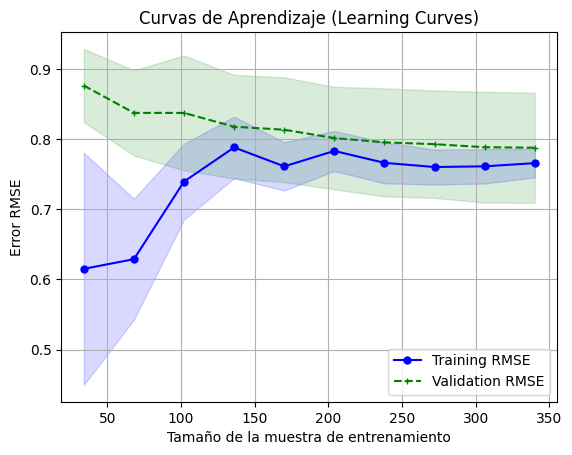

In [107]:
# Ejercicio 4a.

# Al ejecutar las siguientes líneas de código determina si el modelo de
# Bosque Aleatorio con sus valores de hiperparámetros predeterminadas está
# Subentrenado o Sobreentrenado. De ser así, busca los valores de sus
# hiperparámetros que consideres más adecuados para que ya no
# esté sub-o-sobreentrenado:


# ++++++++++++++ Incluye aquí tu código ++++++++++++++++++++++++++++++

elmodelo_RF = RandomForestRegressor(
    n_estimators=300,        
    max_depth=2,             
    min_samples_split=4,      
    min_samples_leaf=1,      
    max_features='log2',      
    bootstrap=True,           
    oob_score=True,          
    random_state=40,
    n_jobs=-1                
)


# +++++++++++++ Tesrmina sección de agregar código +++++++++++++++++++++



mipipe = Pipeline(steps=[('ct',columnasTransformer),('m', elmodelo_RF)])

train_sizes, train_scores, val_scores = learning_curve(estimator=mipipe,
                                                        X=Xtrainval,
                                                        y=np.ravel(ytrainvallog),
                                                        cv=5,
                                                        train_sizes= np.linspace(0.1, 1.0, 10),
                                                        scoring= 'neg_mean_squared_error',  # error MSE
                                                        n_jobs=-1)



# Calculamos los promedios y desviación estándar de entrenamiento para RMSE,
# como tenemos los de MSE, debemos obtener su raíz cuadrada. El negativo es porque
# sklearn nos devuelve en realidad el negativo del Error Cuadrático Medio MSE:

rmse_train_scores = np.sqrt(-train_scores)
rmse_val_scores = np.sqrt(-val_scores)

train_mean = np.mean(rmse_train_scores, axis=1)
train_std = np.std(rmse_train_scores, axis=1, ddof=1)   # aquí también hacemos el ajuste de la desviación estándar muestral.
val_mean = np.mean(rmse_val_scores, axis=1)
val_std = np.std(rmse_val_scores, axis=1, ddof=1)


plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training RMSE')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, val_mean, color='green', marker='+', markersize=5, linestyle='--', label='Validation RMSE')
plt.fill_between(train_sizes, val_mean + val_std, val_mean - val_std, alpha=0.15, color='green')

plt.title('Curvas de Aprendizaje (Learning Curves)')
plt.xlabel('Tamaño de la muestra de entrenamiento')
plt.ylabel('Error RMSE')
plt.grid()
plt.legend(loc='lower right')
plt.show()


In [108]:
# Ejercicio 4b.

# Una vez que verifiques que no está sobreentrenado o subentrenado el modelo,
# podemos calcular el RMSE del mejor ajuste con los datos de Prueba.
# Incluye los valores de tus mejores hiperparámetros encontrados del RandomForest:

# ++++++++++++++ Incluye aquí tus ajustes ++++++++++++++++++++++++++++++


elmodelo_RF = RandomForestRegressor()



# +++++++++++++ Tesrmina sección de realizar ajustes +++++++++++++++++++++


mipipe = Pipeline(steps=[('ct',columnasTransformer),('m', elmodelo_RF)])
mipipe.fit(pd.DataFrame(Xtrainval, columns=Xtrain.columns), np.ravel(ytrainvallog))
yhattest_RF = mipipe.predict(Xtest)

print('Error RSME(Test) de Random Forest: %.3f' % np.sqrt(mean_squared_error(np.ravel(ytestlog), yhattest_RF)))

Error RSME(Test) de Random Forest: 0.716


## **Ejercicio 5**

### **Repite el mismo proceso del Ejercicio 4 anterior para obtener los hiperparámetros que nos lleven a casos de modelos no subentrenados o sobreentrenados, en cada uno de los siguientes casos:**

*   **a. Extreme Gradient Boost XGBoost**
*   **b. Máquina de Vector Soporte SVM**
*   **c. Red Neuronal Perceptrón Multicapa MLP**

In [109]:
# Incluye a continuación las celdas y líneas de código que consideres necesarias
# para responder el Ejercicio 5a, 5b y 5c.


# Definir espacio de búsqueda mejorado para XGBoost
param_grid_xgb = {
    'xgb__n_estimators': [600, 800, 1000], 
    'xgb__max_depth': [4, 5, 3], 
    'xgb__learning_rate': [0.003, 0.005, 0.006],  
    'xgb__subsample': [0.85, 0.9, .9],  
    'xgb__colsample_bytree': [0.85, 0.9, .75],  
    'xgb__gamma': [0.01, 0.02, 0.02], 
    'xgb__reg_alpha': [0.0003, 0.0005, 0.005],  
    'xgb__reg_lambda': [2.0, 2.5, 2.5]  
}

# Definir espacio de búsqueda mejorado para SVM
param_grid_svm = {
    'svm__C': [20, 50, 100, 200], 
    'svm__gamma': [0.001, 0.002, 0.005], 
    'svm__epsilon': [0.02, 0.05, 0.1]  
}

# Definir espacio de búsqueda mejorado para MLP
param_grid_mlp = {
    'mlp__hidden_layer_sizes': [(150, 75), (200, 100), (250, 125)], 
    'mlp__alpha': [0.0003, 0.0005, 0.001],  
    'mlp__learning_rate_init': [0.0003, 0.0005, 0.001],  #
    'mlp__max_iter': [2000, 2500, 3000] 
}

# Definir espacio de búsqueda mejorado para Random Forest
param_grid_rf = {
    'rf__n_estimators': [300, 400, 200],  
    'rf__max_depth': [2, 4, 3],  
    'rf__min_samples_split': [4, 4, 5],  
    'rf__min_samples_leaf': [1, 2, 3],  
    'rf__max_features': ['sqrt', 'log2']  
}


# Función para realizar Randomized Search
def randomized_search(model, param_grid, X, y, cv=5, n_iter=20):
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=-1,
        random_state=7
    )
    random_search.fit(X, y)
    return random_search.best_estimator_, random_search.best_params_

# Crear Pipelines con transformación y modelo
pipeline_xgb = Pipeline(steps=[
    ('ct', columnasTransformer),
    ('xgb', XGBRegressor(random_state=7))
])

pipeline_svm = Pipeline(steps=[
    ('ct', columnasTransformer),
    ('svm', SVR())
])

pipeline_mlp = Pipeline(steps=[
    ('ct', columnasTransformer),
    ('mlp', MLPRegressor(random_state=7))
])

pipeline_rf = Pipeline(steps=[
    ('ct', columnasTransformer),
    ('rf', RandomForestRegressor(random_state=7))
])

# Ejecutar Randomized Search en cada modelo
best_xgb, best_params_xgb = randomized_search(pipeline_xgb, param_grid_xgb, Xtrainval, np.ravel(ytrainvallog))
best_svm, best_params_svm = randomized_search(pipeline_svm, param_grid_svm, Xtrainval, np.ravel(ytrainvallog))
best_mlp, best_params_mlp = randomized_search(pipeline_mlp, param_grid_mlp, Xtrainval, np.ravel(ytrainvallog))
best_rf, best_params_rf = randomized_search(pipeline_rf, param_grid_rf, Xtrainval, np.ravel(ytrainvallog))

# Imprimir los mejores parámetros
print("Mejores parámetros para XGBoost:", best_params_xgb)
print("Mejores parámetros para SVM:", best_params_svm)
print("Mejores parámetros para MLP:", best_params_mlp)
print("Mejores parámetros para Random Forest:", best_params_rf)





Mejores parámetros para XGBoost: {'xgb__subsample': 0.9, 'xgb__reg_lambda': 2.5, 'xgb__reg_alpha': 0.0005, 'xgb__n_estimators': 800, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.005, 'xgb__gamma': 0.02, 'xgb__colsample_bytree': 0.75}
Mejores parámetros para SVM: {'svm__gamma': 0.005, 'svm__epsilon': 0.1, 'svm__C': 100}
Mejores parámetros para MLP: {'mlp__max_iter': 2000, 'mlp__learning_rate_init': 0.0005, 'mlp__hidden_layer_sizes': (250, 125), 'mlp__alpha': 0.001}
Mejores parámetros para Random Forest: {'rf__n_estimators': 400, 'rf__min_samples_split': 4, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 'rf__max_depth': 4}


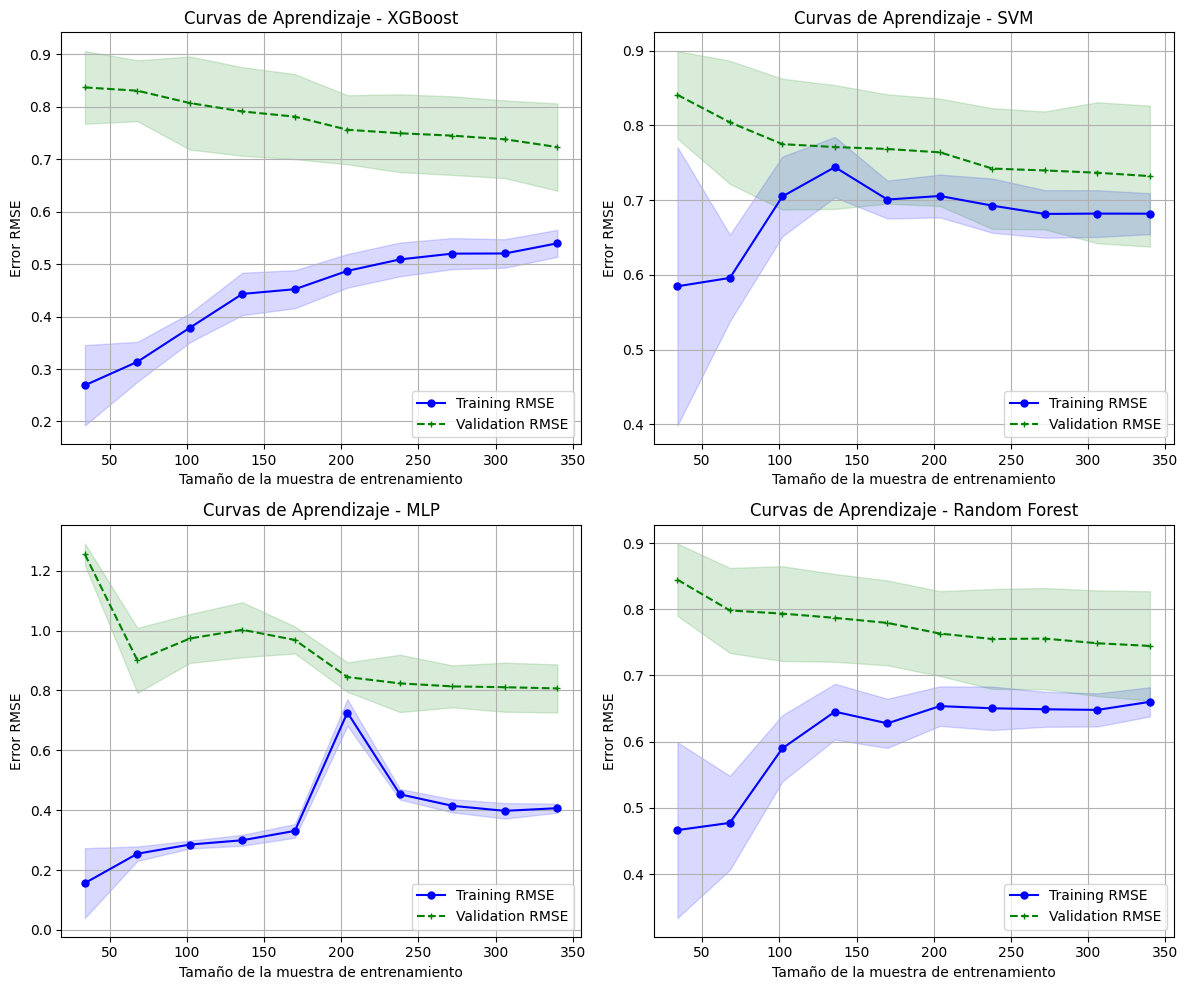

In [110]:
# Función para limpiar los nombres de los hiperparámetros eliminando los prefijos del Pipeline
def clean_param_names(best_params, prefix):
    return {key.replace(f"{prefix}__", ""): value for key, value in best_params.items()}

# Limpiar parámetros para cada modelo
best_params_xgb_clean = clean_param_names(best_params_xgb, "xgb")
best_params_svm_clean = clean_param_names(best_params_svm, "svm")
best_params_mlp_clean = clean_param_names(best_params_mlp, "mlp")
best_params_rf_clean = clean_param_names(best_params_rf, "rf")

# Diccionario con los modelos optimizados y sus nombres
optimized_models = {
    "XGBoost": XGBRegressor(**best_params_xgb_clean, random_state=7),
    "SVM": SVR(**best_params_svm_clean),
    "MLP": MLPRegressor(**best_params_mlp_clean, random_state=7),
    "Random Forest": RandomForestRegressor(**best_params_rf_clean, random_state=7)
}

# Generar curvas de aprendizaje comparativas para los 4 modelos
titles = list(optimized_models.keys())
plt.figure(figsize=(12, 10))

for i, (model_name, model) in enumerate(optimized_models.items(), 1):
    mipipe = Pipeline(steps=[('ct', columnasTransformer), ('m', model)])

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=mipipe,
        X=Xtrainval,
        y=np.ravel(ytrainvallog),
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_mean_squared_error',  
        n_jobs=-1
    )

    # Calcular RMSE para entrenamiento y validación
    rmse_train_scores = np.sqrt(-train_scores)
    rmse_val_scores = np.sqrt(-val_scores)

    train_mean = np.mean(rmse_train_scores, axis=1)
    train_std = np.std(rmse_train_scores, axis=1, ddof=1)  # Ajuste para desviación estándar muestral
    val_mean = np.mean(rmse_val_scores, axis=1)
    val_std = np.std(rmse_val_scores, axis=1, ddof=1)

    # Graficar curvas de aprendizaje en subgráficos
    plt.subplot(2, 2, i)
    plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training RMSE')
    plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')
    plt.plot(train_sizes, val_mean, color='green', marker='+', markersize=5, linestyle='--', label='Validation RMSE')
    plt.fill_between(train_sizes, val_mean + val_std, val_mean - val_std, alpha=0.15, color='green')
    plt.title(f'Curvas de Aprendizaje - {model_name}')
    plt.xlabel('Tamaño de la muestra de entrenamiento')
    plt.ylabel('Error RMSE')
    plt.grid()
    plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

## **Ejercicio 6**

### **Importancia de características**

#### **Ejercicio 6a.**

*   **Con base al mejor modelo encontrado, realiza una análisis de importancia de características con el conjunto de prueba (Test).**

*   **Obtener un diagrama de cajas o algún tipo de visualización para mostrar estos resultados.**


#### **Ejercicio 6b.**

*   **Con base a los gráficos obtenidos indica cuáles son los tres factores más importantes y que dan mayor información para la predicción de la variable de salida.**

*  **Compara tus resultados con el resultado de la Figura 6 del artículo de ELSEVIER. Indica tus coincidencias y diferencias.**

Text(0.5, 1.0, 'Importancia de las Variables en el Modelo')

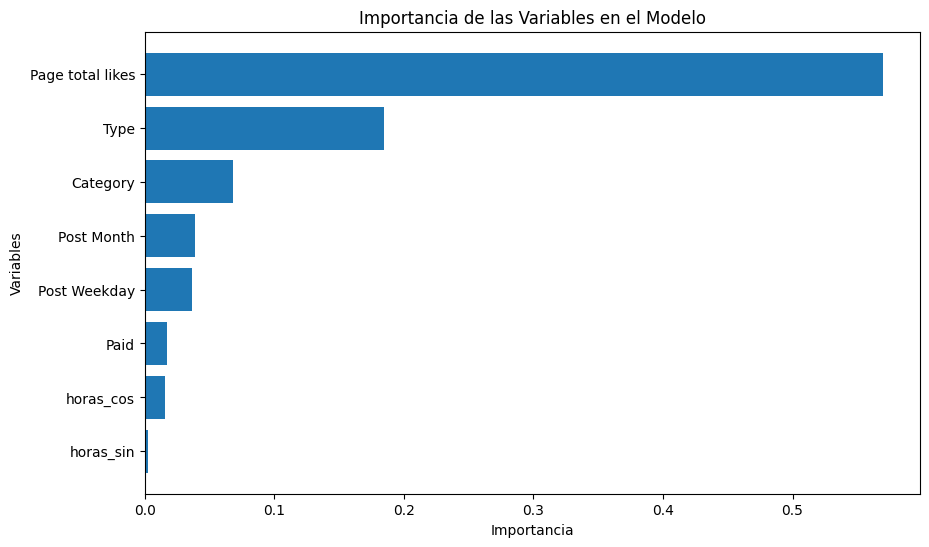

In [ ]:
# ++++++++++++++ Incluye aquí tu código +++++++++++++++++++++++++++++++
# Ejercicio 6a.


best_model = best_xgb.named_steps['xgb'] 



mipipefinal = Pipeline(steps=[('ct',columnasTransformer), ('m', elmodelo_RF)])
mipipefinal.fit(pd.DataFrame(Xtrainval, columns=Xtrainval.columns), np.ravel(ytrainvallog))
result = permutation_importance(mipipefinal, Xtest, np.ravel(ytestlog), n_repeats=10, random_state=42, n_jobs=-1)
columnas = X.columns

coef_df = pd.DataFrame({
    'Variable': columnas,
    'Importancia': np.abs(result.importances_mean)
})

coef_df = coef_df.sort_values(by='Importancia', ascending=False)


plt.figure(figsize=(10, 6))

plt.barh(coef_df['Variable'], coef_df['Importancia'])

plt.gca().invert_yaxis()

plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.title('Importancia de las Variables en el Modelo')


# +++++++++++++ Termina sección de agregar código +++++++++++++++++++++



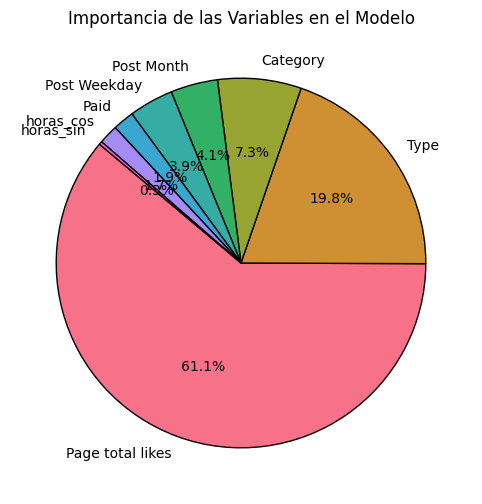

In [112]:

colors = sns.color_palette("husl", len(coef_df))

# Gráfico de pastel
plt.figure(figsize=(10, 6))
plt.pie(coef_df['Importancia'], labels=coef_df['Variable'], autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops={'edgecolor': 'black'})

# Título
plt.title('Importancia de las Variables en el Modelo')

# Mostrar gráfico
plt.show()


### ++++++++ Inicia la sección de agregar texto: +++++++++++
### **Ejercicio 6b**
Según el gráfico de importancia de características obtenido, los tres factores más relevantes para la predicción de la variable de salida son:

Page total likes (Total de 'me gusta' de la página)
Es la característica con mayor peso en la predicción. Indica que la cantidad de seguidores de la página influye significativamente en la interacción de los usuarios con las publicaciones. A mayor cantidad de "me gusta", es más probable que un post tenga un mayor alcance y número de interacciones.

Type (Tipo de contenido)
Esta variable también juega un papel crucial en la predicción. Indica que el tipo de publicación (imagen, video, enlace, estado) puede afectar directamente el nivel de interacción y consumo de los usuarios.

Category (Categoría del contenido)
Representa la clasificación del contenido publicado (producto, acción, inspiración). Su importancia sugiere que el tipo de mensaje o temática del post influye en el nivel de interacción y consumo del público.

Coincidencias con el artículo de ELSEVIER

"Page total likes" también es una variable clave en el artículo, lo que confirma que una mayor cantidad de seguidores está asociada con mayor interacción en las publicaciones.

"Type" (Tipo de contenido) se destaca en ambos análisis como una variable relevante, lo que refuerza la idea de que el formato de la publicación afecta significativamente su desempeño.

"Category" también es mencionada en el artículo, lo que sugiere que el tipo de contenido es un factor determinante en la interacción del usuario.

Diferencias con el artículo

En el artículo, "Post hour" y "Post month" tienen un mayor impacto en comparación con nuestro análisis, lo que sugiere que la estacionalidad y la hora de publicación pueden influir más en la interacción de lo que se refleja en nuestro modelo.
En nuestra gráfica, "Post weekday" tiene menor relevancia en comparación con los hallazgos del artículo, lo que indica que el día de la semana no es un factor tan determinante en la predicción de la variable de salida.


### ++++++++ Termina la sección de agregar texto. +++++++++++

## **Ejercicio 7**

### **Incluye tus conclusiones finales de la Actividad.**

### ++++++++ Inicia la sección de agregar texto: +++++++++++

En esta tarea, se implementó un modelo basado en XGBoost para predecir la interacción con publicaciones en páginas de Facebook, utilizando un conjunto de características extraídas del artículo "Predicting Lifetime Post Consumers on Facebook Brand Pages" de Moro et al.. A través del análisis de importancia de características y la comparación con los hallazgos del artículo, se identificaron los factores clave que influyen en la variable de salida, validando en gran medida los resultados obtenidos en estudios previos.

Optimización de horarios de publicación:
Los administradores de páginas de Facebook pueden programar sus publicaciones en horarios estratégicos para maximizar la visibilidad y la interacción.

Análisis de estacionalidad:
Identificar meses de mayor impacto en las interacciones permite diseñar estrategias de contenido alineadas con estos períodos.

Estrategias de crecimiento de audiencia:
Dado que la cantidad de "me gusta" en la página es un factor clave, se recomienda implementar campañas de marketing digital para atraer nuevos seguidores y fortalecer la base de usuarios activos.

Puntos de Mejora
Exploración de otros modelos:
Probar arquitecturas más complejas, como redes neuronales o modelos híbridos, para evaluar mejoras en la predicción.

Incorporación de nuevas variables:
Agregar características como la frecuencia de publicaciones o métricas avanzadas de engagement podría enriquecer el análisis.


Este estudio proporciona información valiosa sobre los factores que impactan la interacción en redes sociales, validando en gran parte los hallazgos de la literatura. A través de técnicas avanzadas de Machine Learning, se ha demostrado que el tipo de contenido, la base de seguidores y la categorización de los posts son determinantes en el comportamiento de los consumidores digitales.

Estos resultados pueden ser utilizados por empresas y especialistas en marketing digital para optimizar sus estrategias de contenido y mejorar el rendimiento de sus publicaciones en plataformas sociales. Además, se resalta la importancia de un adecuado entrenamiento del modelo, la selección de características y el entendimiento del problema para obtener resultados robustos y aplicables en la toma de decisiones estratégicas.




### ++++++++ Termina la sección de agregar texto. +++++++++++

>> **Fin de la Actividad de la Semana 7**